# EDA Part 2: Relationships, Correlation & Feature Analysis

After profiling your data — checking shape, types, missing values, and distributions — the next step is to understand how features relate to each other and to the target variable. This is where EDA directly informs your modeling choices: which features are likely to be predictive, which are redundant, and which might cause problems. Correlation analysis and relationship plots are the primary tools for this investigation.

<div style="background-color:#1e293b;padding:15px;border-left:6px solid #38bdf8;color:#e2e8f0">

<b>EDA Checklist</b> — run through this for every new dataset

<ol>
<li>Check shape (rows, columns)</li>
<li>Check dtypes and flag unexpected types</li>
<li>Check missing values: count and %</li>
<li>Check distributions: numerical (histograms) and categorical (bar charts)</li>
<li><b>Check correlations with target</b> — this notebook</li>
<li><b>Identify potential issues: outliers, skewness, high-cardinality columns</b> — this notebook</li>
</ol>

</div>

<div style="background-color:#1e293b;padding:15px;border-left:6px solid #38bdf8;color:#e2e8f0">

<b>What you will learn</b>

- Visualize how a target variable varies across feature categories (boxplots)
- Build and interpret a correlation heatmap
- Identify outliers and skewed features that need treatment before modeling

<b>Dataset:</b> AI/ML Job Salaries — global salary data for data science roles (2020-2024). Target variable: <code>salary_in_usd</code>.

</div>

---
## Step 1: Setup and Loading Data

In [3]:
import pandas as pd
import matplotlib.pyplot as plt  # base plotting library
import seaborn as sns             # statistical plots built on top of matplotlib
import numpy as np                # numerical computing; used here for log transforms and number type selection

sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('salaries.csv')
print("Shape:", df.shape)

Shape: (73148, 11)


---
## Step 2: Feature vs Target

To understand which features relate to salary, we compare the salary distribution across each feature's categories using boxplots.

A boxplot shows: median (middle line), IQR (box), outliers (dots).

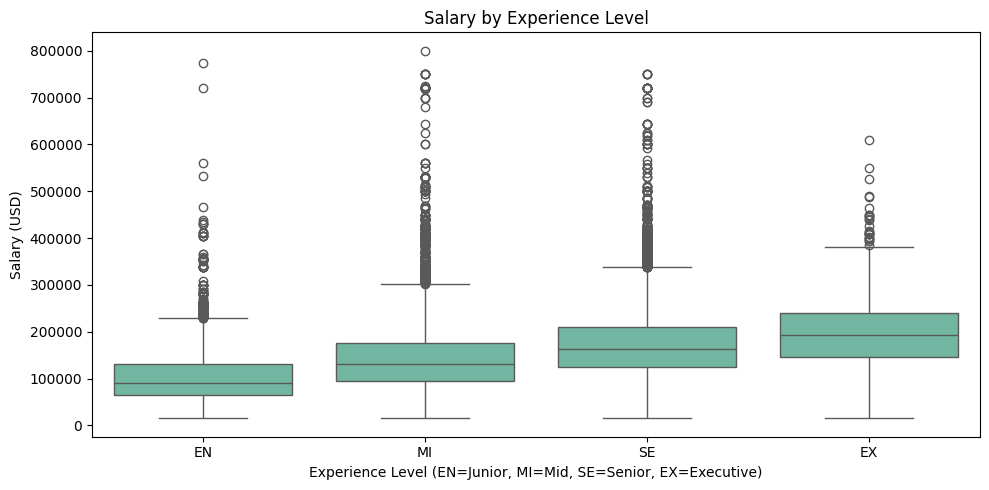

                    median      mean  count
experience_level                           
EN                 89700.0  101701.0   6877
MI                130800.0  142892.0  21851
SE                162100.0  173298.0  42926
EX                192168.0  199244.0   1494


In [4]:
# Salary by experience level — ordered EN → MI → SE → EX
exp_order = ['EN', 'MI', 'SE', 'EX']

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df, x='experience_level', y='salary_in_usd',
    order=exp_order,  # display in career-progression order, not alphabetical
    ax=ax             # draw on this specific axes object (needed when using subplots)
)
ax.set_title('Salary by Experience Level')
ax.set_xlabel('Experience Level (EN=Junior, MI=Mid, SE=Senior, EX=Executive)')
ax.set_ylabel('Salary (USD)')
plt.tight_layout()
plt.show()

print(df.groupby('experience_level')['salary_in_usd']
        .agg(median='median', mean='mean', count='count')
        .loc[exp_order].round(0))

**Observation:** Salary increases with experience, but not linearly. The jump from MI to SE is large; the jump from SE to EX is a bit smaller and EX has fewer data points (wider box, more uncertainty). The many outlier dots show high-earners at every level — experience level alone does not fully explain salary.

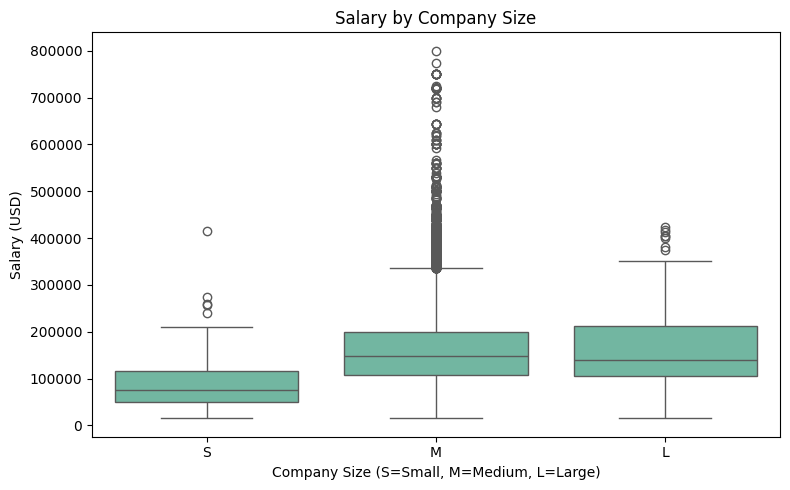

                median      mean  count
company_size                           
S              75000.0   87678.0    205
M             148000.0  158345.0  70536
L             138643.0  154302.0   2407


In [5]:
# Salary by company size — ordered S → M → L
size_order = ['S', 'M', 'L']

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='company_size', y='salary_in_usd', order=size_order, ax=ax)
ax.set_title('Salary by Company Size')
ax.set_xlabel('Company Size (S=Small, M=Medium, L=Large)')
ax.set_ylabel('Salary (USD)')
plt.tight_layout()
plt.show()

print(df.groupby('company_size')['salary_in_usd']
        .agg(median='median', mean='mean', count='count')
        .loc[size_order].round(0))

   work_year  mean_salary  median_salary  count
0       2020     102251.0        79833.0     75
1       2021      99922.0        83872.0    218
2       2022     134184.0       131300.0   1659
3       2023     153701.0       145000.0   8522
4       2024     159611.0       148960.0  62228
5       2025     144022.0       136100.0    446


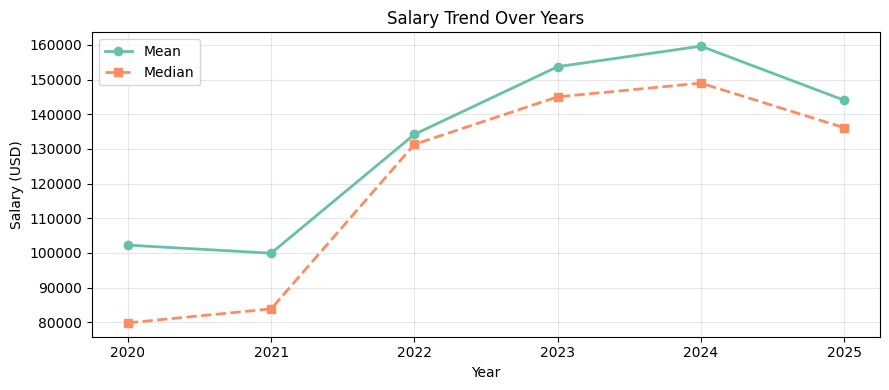

In [6]:
# Salary trend over years
yearly = (df.groupby('work_year')['salary_in_usd']
            .agg(mean_salary='mean', median_salary='median', count='count')
            .reset_index().round(0))
print(yearly)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(yearly['work_year'], yearly['mean_salary'],
        marker='o', linewidth=2, label='Mean')
ax.plot(yearly['work_year'], yearly['median_salary'],
        marker='s', linewidth=2, linestyle='--', label='Median')
ax.set_title('Salary Trend Over Years')
ax.set_xlabel('Year')
ax.set_ylabel('Salary (USD)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:** The chart shows mean and median salary declining from 2023 onward — but this does not mean ML salaries are falling. It is a composition effect: the dataset accumulated many more junior and mid-level roles in 2024-2025, pulling the aggregate down even if salaries within each level stayed flat or rose. When a trend looks surprising, check whether the mix of groups in your data changed — aggregate statistics can mislead when the underlying composition shifts.

**TODO:** Plot salary distribution grouped by `remote_ratio`. Which remote policy has the highest median salary? Does the result surprise you?

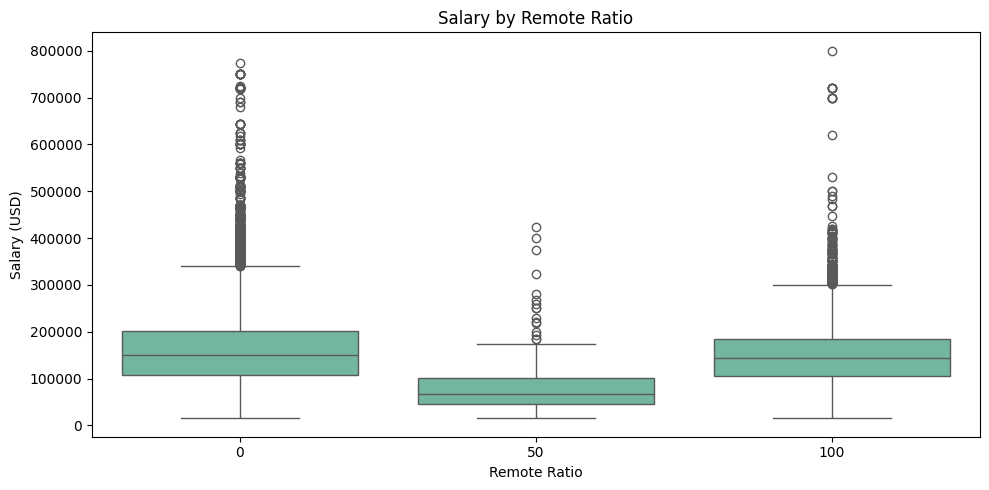

   remote_ratio  mean_salary  median_salary  count
0             0     160858.0       149282.0  57220
1            50      82361.0        66970.0    281
2           100     148971.0       144300.0  15647


In [ ]:
# YOUR TURN
remote_ratio_df = (df.groupby('remote_ratio')['salary_in_usd']
            .agg(mean_salary='mean', median_salary='median', count='count')
            .reset_index().round(0))

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df, x='remote_ratio', y='salary_in_usd',
    ax=ax             # draw on this specific axes object (needed when using subplots)
)
ax.set_title('Salary by Remote Ratio')
ax.set_xlabel('Remote Ratio')
ax.set_ylabel('Salary (USD)')
plt.tight_layout()
plt.show()

print(remote_ratio_df)

# Fully onsite policy has the biggest mean and median salary, 
# 50 - has to be investigated, and correlation found. But count of it seems like not representing
# I would expect a higher salary for fully remote jobs, but the data shows the opposite. 


<details><summary><b>Solution — click to expand</b></summary>

```python
remote_order = [0, 50, 100]
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='remote_ratio', y='salary_in_usd', order=remote_order, ax=ax)
ax.set_title('Salary by Remote Ratio')
ax.set_xlabel('Remote Ratio (0=on-site, 50=hybrid, 100=fully remote)')
ax.set_ylabel('Salary (USD)')
plt.tight_layout()
plt.show()

print(df.groupby('remote_ratio')['salary_in_usd']
        .agg(median='median', mean='mean', count='count')
        .round(0))
```
</details>

---
## Step 3: Correlation Matrix

The correlation coefficient measures the linear relationship between two numerical features. It ranges from -1 (perfect negative) to +1 (perfect positive), with 0 meaning no linear relationship.

A **heatmap** visualizes all pairwise correlations at once.

In [13]:
# Correlation matrix for numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()  # np.number matches int64, float64, etc.
print("Numerical columns:", numerical_cols)

corr_matrix = df[numerical_cols].corr()
print("\nCorrelation matrix:")
print(corr_matrix.round(3))

Numerical columns: ['work_year', 'salary', 'salary_in_usd', 'remote_ratio']

Correlation matrix:
               work_year  salary  salary_in_usd  remote_ratio
work_year          1.000  -0.046          0.065        -0.171
salary            -0.046   1.000          0.337        -0.002
salary_in_usd      0.065   0.337          1.000        -0.070
remote_ratio      -0.171  -0.002         -0.070         1.000


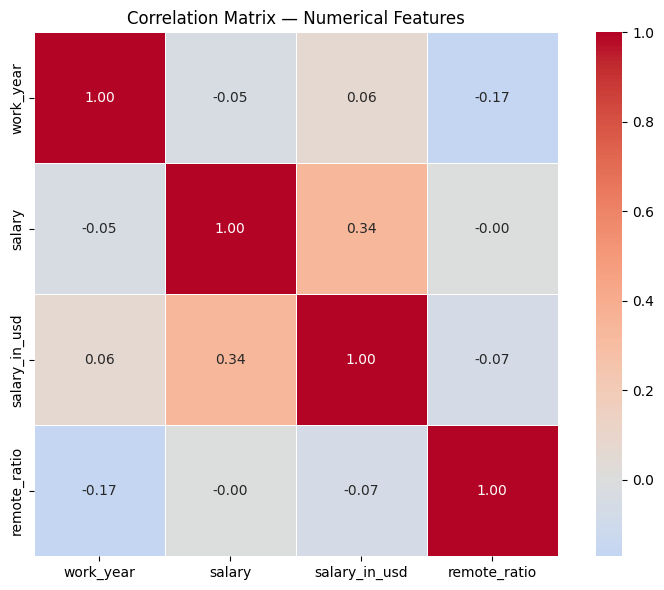

In [14]:
# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,       # show correlation value in each cell
    fmt='.2f',        # format values to 2 decimal places
    cmap='coolwarm',  # red = positive correlation, blue = negative
    center=0,         # white = no correlation (center of the color scale)
    square=True,      # equal cell dimensions
    linewidths=0.5    # thin grid lines between cells
)
plt.title('Correlation Matrix — Numerical Features')
plt.tight_layout()
plt.show()

**Reading the heatmap:**
- Dark red = strong positive correlation (+1)
- Dark blue = strong negative correlation (-1)
- White/light = little or no linear correlation
- The diagonal is always 1.0 (a feature perfectly correlates with itself)

As a rough guide: |r| < 0.3 is weak, 0.3–0.7 is moderate, > 0.7 is strong. In real datasets, a single feature with |r| > 0.4 against the target is often meaningful — perfect correlations are rare.

For this dataset the raw numerical columns are limited. `.corr()` only works on numbers, so categorical columns like `experience_level` are automatically excluded. To include them, we assign a number to each category — this is called **encoding**:

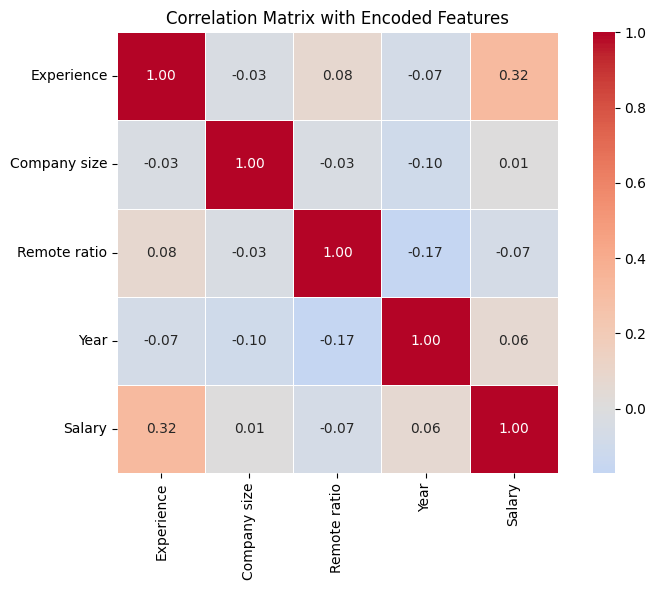

In [15]:
# Encode ordinal features numerically for correlation analysis
df_encoded = df.copy()

exp_map = {'EN': 1, 'MI': 2, 'SE': 3, 'EX': 4}
size_map = {'S': 1, 'M': 2, 'L': 3}

df_encoded['exp_num'] = df_encoded['experience_level'].map(exp_map)
df_encoded['size_num'] = df_encoded['company_size'].map(size_map)

cols_for_corr = ['exp_num', 'size_num', 'remote_ratio', 'work_year', 'salary_in_usd']
corr_encoded = df_encoded[cols_for_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_encoded,
    annot=True,       # show correlation value in each cell
    fmt='.2f',        # format values to 2 decimal places
    cmap='coolwarm',  # red = positive correlation, blue = negative
    center=0,         # white = no correlation (center of the color scale)
    square=True,      # equal cell dimensions
    linewidths=0.5,   # thin grid lines between cells
    xticklabels=['Experience', 'Company size', 'Remote ratio', 'Year', 'Salary'],
    yticklabels=['Experience', 'Company size', 'Remote ratio', 'Year', 'Salary']
)
plt.title('Correlation Matrix with Encoded Features')
plt.tight_layout()
plt.show()

**Interpretation:**
- `exp_num` (experience level) has the strongest correlation with salary — as expected
- `work_year` shows a weak positive correlation (r ≈ 0.07) — this partially reflects the upward trend from 2020 to 2022, but as we saw in the trend plot, the aggregate reverses from 2023 onward
- `remote_ratio` and `company_size` show near-zero correlation with salary

> **Correlation ≠ causation.** These correlations describe the dataset, not necessarily the real world. An executive in a large company earns more on average, but you cannot conclude that company size *causes* higher pay.

> **Correlation only captures linear relationships.** A feature can be highly important for a model while showing low linear correlation with the target (if the relationship is curved or depends on interactions).

---
## Step 4: Scatter Plots — Numerical Feature Relationships

Scatter plots show the relationship between two numerical features directly. They reveal non-linear patterns, clusters, and outliers that correlation coefficients miss.

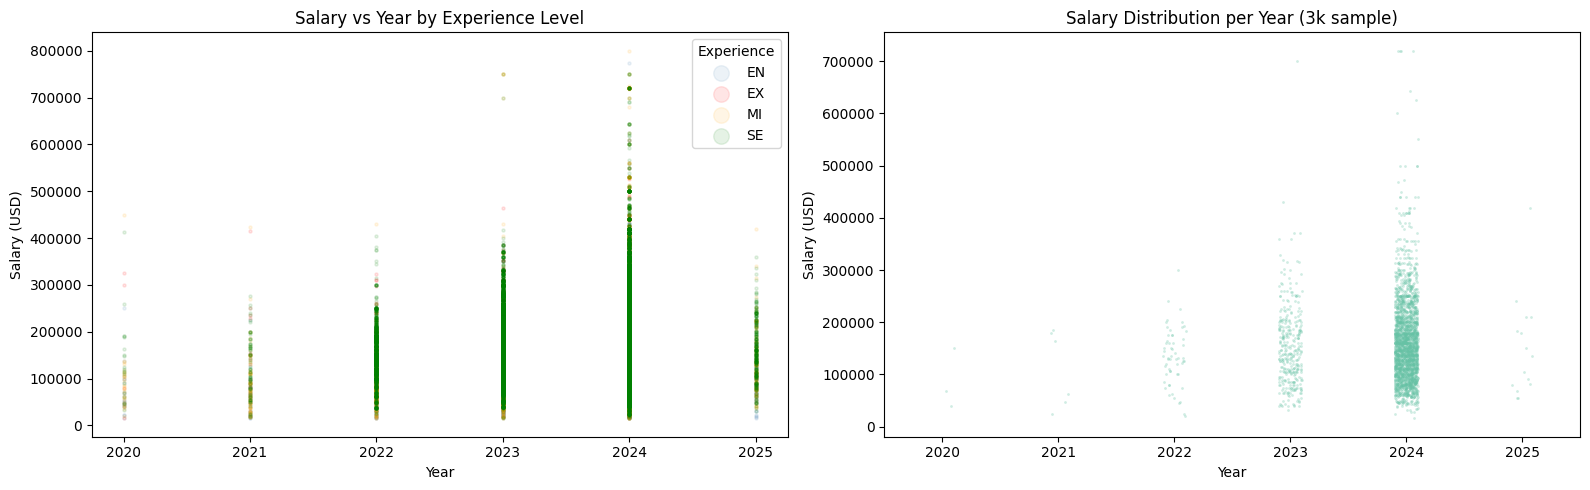

In [22]:
# Scatter: salary vs work_year, colored by experience level
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# Left: salary over years
colors = {'EN': 'steelblue', 'MI': 'orange', 'SE': 'green', 'EX': 'red'}
for level, group in df.groupby('experience_level'):
    axes[0].scatter(
        group['work_year'], group['salary_in_usd'],
        alpha=0.1,                        # transparency — reduces overplotting with 70k points
        s=5,                              # marker size in points²
        color=colors.get(level, 'gray'),
        label=level
    )
axes[0].set_title('Salary vs Year by Experience Level')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Salary (USD)')
axes[0].legend(title='Experience', markerscale=5)  # markerscale enlarges legend dots for visibility

# Right: salary distribution by year (strip plot — less overlapping than scatter for this data)
sns.stripplot(
    data=df.sample(3000, random_state=42),  # sample to keep the plot readable
    x='work_year', y='salary_in_usd',
    alpha=0.3,                              # transparency
    size=2,                                 # dot size
    ax=axes[1]
)
axes[1].set_title('Salary Distribution per Year (3k sample)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Salary (USD)')

plt.tight_layout()
plt.show()

**Observation:** The left scatter plot separates experience levels by color. You can see that senior (SE, green) and executive (EX, red) points sit higher. Entry-level (EN, blue) points are concentrated lower but have some extreme outliers — worth investigating. The right strip plot shows salary range widening over time (more high earners in 2024-2025), consistent with what we saw in the trend line.

---
## Step 5: Outliers & Skewness

### Skewness

**Skewness** measures how asymmetric a distribution is. A value of 0 is perfectly symmetric. Positive = right tail (a few very large values pull the mean up). Negative = left tail. Rule of thumb: |skewness| < 0.5 roughly symmetric, 0.5–1.0 moderate, > 1.0 notably skewed — worth addressing before modeling.

In [23]:
# Skewness of numerical columns
skewness = df[numerical_cols].skew().round(3)
print("Skewness per column (|value| > 1 = notably skewed):")
print(skewness)
print()
print("Interpretation:")
for col, skew in skewness.items():
    if abs(skew) > 1:
        direction = 'right (positive)' if skew > 0 else 'left (negative)'
        print(f"  {col}: skewed {direction} ({skew:.2f})")
    else:
        print(f"  {col}: approximately symmetric ({skew:.2f})")

Skewness per column (|value| > 1 = notably skewed):
work_year        -2.917
salary           70.521
salary_in_usd     1.216
remote_ratio      1.382
dtype: float64

Interpretation:
  work_year: skewed left (negative) (-2.92)
  salary: skewed right (positive) (70.52)
  salary_in_usd: skewed right (positive) (1.22)
  remote_ratio: skewed right (positive) (1.38)


### Outlier Detection with IQR (Interquartile Range)

**Q1** (25th percentile) is the value below which 25% of your data falls. **Q3** (75th percentile) is the value below which 75% falls. The **IQR** is the range of the middle 50% of the data: Q3 − Q1.

A standard statistical rule flags values more than 1.5 × IQR below Q1 or above Q3 as outliers. The 1.5 multiplier is a convention — it captures roughly the outermost 0.7% of a normal distribution. For extreme outliers we can use 3.0 ×.

In [24]:
# IQR-based outlier detection for salary
Q1 = df['salary_in_usd'].quantile(0.25)
Q3 = df['salary_in_usd'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['salary_in_usd'] < lower_bound) | (df['salary_in_usd'] > upper_bound)]

print(f"IQR: ${IQR:,.0f}")
print(f"Lower bound: ${lower_bound:,.0f}")
print(f"Upper bound: ${upper_bound:,.0f}")
print(f"Outliers: {len(outliers)} rows ({len(outliers)/len(df)*100:.1f}%)")
print(f"\nOutlier salary range: ${outliers['salary_in_usd'].min():,.0f} - ${outliers['salary_in_usd'].max():,.0f}")

IQR: $92,810
Lower bound: $-32,325
Upper bound: $338,915
Outliers: 1369 rows (1.9%)

Outlier salary range: $339,250 - $800,000


> **Note:** The lower bound is negative ($-32,325). That is expected — when Q1 − 1.5 × IQR drops below zero, it simply means no salary in this dataset is unusually low. Salaries cannot be negative, so there are no lower outliers. All 1,369 flagged outliers are on the high end.

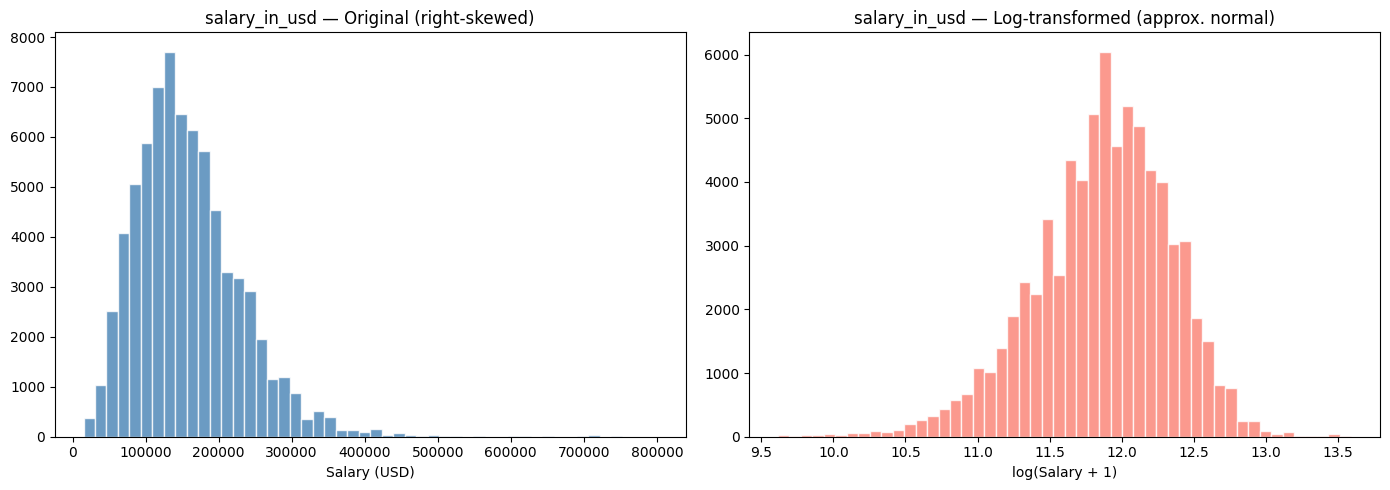

Original skewness: 1.216
Log-transformed skewness: -0.516


In [41]:
# Log transform: common fix for right-skewed salary data
df['salary_log'] = np.log1p(df['salary_in_usd'])  # log1p = log(1 + x), handles zeros safely

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['salary_in_usd'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('salary_in_usd — Original (right-skewed)')
axes[0].set_xlabel('Salary (USD)')

axes[1].hist(df['salary_log'], bins=50, color='salmon', edgecolor='white', alpha=0.8)
axes[1].set_title('salary_in_usd — Log-transformed (approx. normal)')
axes[1].set_xlabel('log(Salary + 1)')

plt.tight_layout()
plt.show()

print(f"Original skewness: {df['salary_in_usd'].skew():.3f}")
print(f"Log-transformed skewness: {df['salary_log'].skew():.3f}")

> A **transformation** applies a mathematical function to every value in a column to change its scale or distribution shape — the values change, but the row order stays the same.
>
> **Why log-transform?** The logarithm transformation specifically compresses large values while preserving order: log(150,000) ≈ 11.9 and log(800,000) ≈ 13.6 — a 5× salary difference shrinks to a 1.7-unit gap in log space. This prevents a handful of extreme salaries from pulling the model's predictions disproportionately toward high values, and makes the distribution more symmetric, which most models fit better. `np.log1p` (log(1 + x)) is used instead of `np.log` to safely handle zero values — log(0) is undefined.
>
> When you eventually predict on a log-transformed target, use `np.expm1(prediction)` to convert back to the original scale (`expm1` is the inverse of `log1p`).

**TODO:** Check the skewness of the original `salary` column (not `salary_in_usd`). Is it more or less skewed than `salary_in_usd`? Why might they differ?

       work_year experience_level employment_type  \
73069       2021               MI              FT   
24237       2024               MI              FT   
73048       2020               MI              FT   
72978       2021               MI              FT   
72885       2021               MI              FT   
72382       2022               SE              FT   
72886       2021               MI              FT   
73147       2021               SE              FT   
71784       2022               EN              FT   
33515       2024               SE              FT   

                            job_title    salary salary_currency  \
73069                  Data Scientist  30400000             CLP   
24237                        Engineer  12000000             JPY   
73048                  Data Scientist  11000000             HUF   
72978                 BI Data Analyst  11000000             HUF   
72885       Machine Learning Engineer   8500000             JPY   
72382  Lead Ma

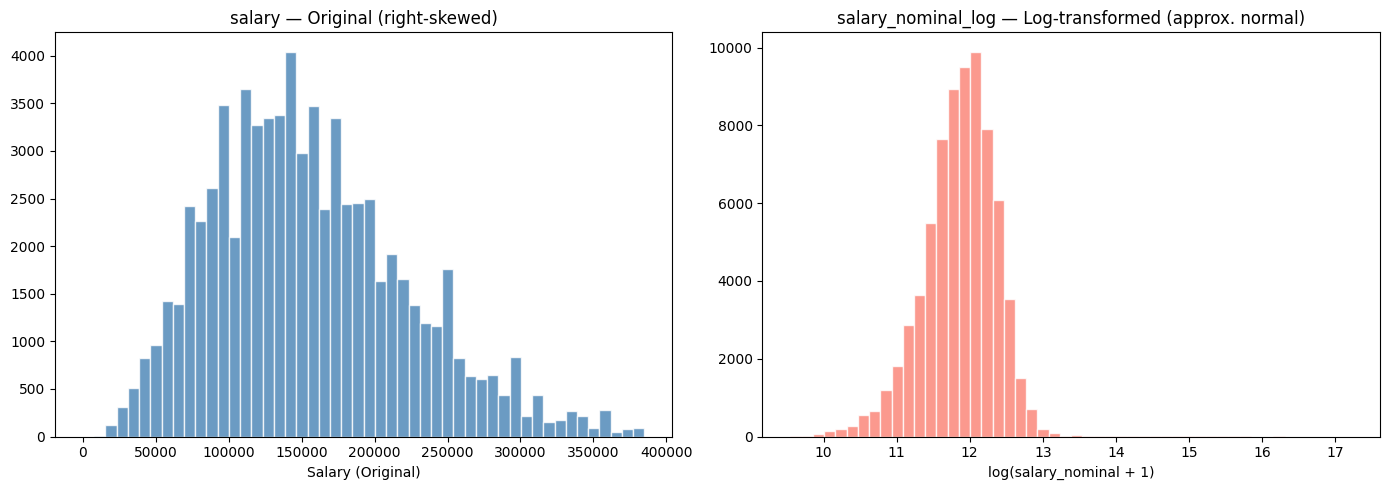

Original skewness: 70.521
Log-transformed skewness: -0.228


In [61]:
# YOUR TURN
df['salary_nominal_log'] = np.log1p(df['salary'])  # log1p = log(1 + x), handles zeros safely

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['salary'], bins=50, color='steelblue', edgecolor='white', alpha=0.8, range=(0, df['salary'].quantile(0.99)))  # limit x-axis to 99th percentile for better visualization
salary_outliers = df[df['salary'] > df['salary'].quantile(0.99)]
print(salary_outliers.sort_values('salary', ascending=False).head(10))  # show top 10 outliers

axes[0].set_title('salary — Original (right-skewed)')
axes[0].set_xlabel('Salary (Original)')

axes[1].hist(df['salary_nominal_log'], bins=50, color='salmon', edgecolor='white', alpha=0.8)
axes[1].set_title('salary_nominal_log — Log-transformed (approx. normal)')
axes[1].set_xlabel('log(salary_nominal + 1)')

plt.tight_layout()
plt.show()

print(f"Original skewness: {df['salary'].skew():.3f}")
print(f"Log-transformed skewness: {df['salary_nominal_log'].skew():.3f}")


<details><summary><b>Solution — click to expand</b></summary>

```python
print(f"salary skewness:        {df['salary'].skew():.3f}")
print(f"salary_in_usd skewness: {df['salary_in_usd'].skew():.3f}")
print("\nNote: salary is in the original currency (USD, EUR, GBP, etc.).")
print("The currency mix adds extra spread. salary_in_usd is more comparable.")
```
</details>

---
## Step 6: Bringing It Together

Which job titles have the highest median salaries?

In [36]:
# Aggregate median salary per job title — filter to titles with at least 20 records
title_stats = (df.groupby('job_title')['salary_in_usd']
                 .agg(median='median', count='count')
                 .reset_index())
title_stats_filtered = title_stats[title_stats['count'] >= 20]
print(title_stats_filtered.sort_values('median', ascending=False).head(10))
print()
print(f"{len(title_stats)} total job titles, {len(title_stats_filtered)} with 20+ records")

                                     job_title    median  count
170                        Engineering Manager  239800.0    366
180                               Head of Data  225000.0    164
8                           AI Product Manager  197000.0     27
0                                 AI Architect  196500.0    147
285                             Technical Lead  192800.0     72
195                  Machine Learning Engineer  187500.0   5807
257                         Research Scientist  184300.0   2283
80                    Computer Vision Engineer  183795.0     88
232  Principal Application Delivery Consultant  182500.0     40
106               Data Infrastructure Engineer  181605.0     74

289 total job titles, 123 with 20+ records


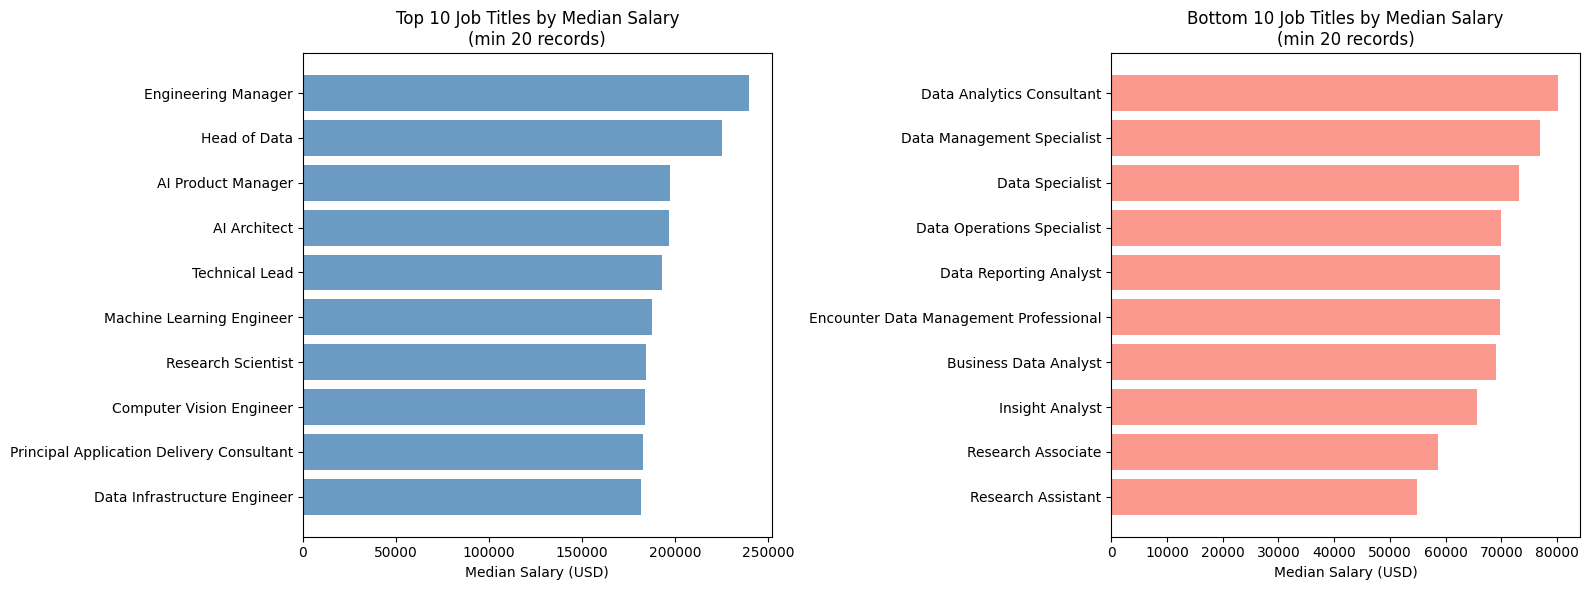

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10
top_10 = title_stats_filtered.nlargest(10, 'median')
axes[0].barh(top_10['job_title'], top_10['median'], color='steelblue', alpha=0.8)
axes[0].set_title('Top 10 Job Titles by Median Salary\n(min 20 records)')
axes[0].set_xlabel('Median Salary (USD)')
axes[0].invert_yaxis()  # puts the highest-paid title at the top of the chart

# Bottom 10
bottom_10 = title_stats_filtered.nsmallest(10, 'median').sort_values('median', ascending=False)  # sort so lowest is at the bottom of the chart
axes[1].barh(bottom_10['job_title'], bottom_10['median'], color='salmon', alpha=0.8)
axes[1].set_title('Bottom 10 Job Titles by Median Salary\n(min 20 records)')
axes[1].set_xlabel('Median Salary (USD)')
axes[1].invert_yaxis()  # puts the lowest-paid title at the top of the chart

plt.tight_layout()
plt.show()

---
## Summary

You have completed the full EDA checklist:

1. **Shape** — rows, columns confirmed
2. **Dtypes** — types identified, `remote_ratio` noted as ordinal
3. **Missing values** — no missing data in this dataset
4. **Distributions** — salary is right-skewed; `employment_type` is imbalanced; `job_title` is high-cardinality
5. **Correlations** — experience level has the strongest linear relationship with salary
6. **Issues** — right skew in salary (log transform helps), outliers above the IQR bound

**Key findings for modeling:**
- `experience_level` is the most important feature
- `salary_in_usd` needs a log transform before use as a regression target
- `employment_type` is nearly constant — may not add predictive value
- `job_title` requires grouping or encoding before use